In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings('ignore')


In [79]:
df = pd.read_csv("electric_vehicles_spec_2025.csv")
df.head()


,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [80]:
df.isnull().sum() * 100/len(df)

brand                         0.000000
model                         0.209205
top_speed_kmh                 0.000000
battery_capacity_kWh          0.000000
battery_type                  0.000000
number_of_cells              42.259414
torque_nm                     1.464435
efficiency_wh_per_km          0.000000
range_km                      0.000000
acceleration_0_100_s          0.000000
fast_charging_power_kw_dc     0.209205
fast_charge_port              0.209205
towing_capacity_kg            5.439331
cargo_volume_l                0.209205
seats                         0.000000
drivetrain                    0.000000
segment                       0.000000
length_mm                     0.000000
width_mm                      0.000000
height_mm                     0.000000
car_body_type                 0.000000
source_url                    0.000000
dtype: float64

In [81]:
### Changing datatypes

df['cargo_volume_l'] = pd.to_numeric(df['cargo_volume_l'], errors='coerce')
df.astype({'battery_capacity_kWh' : float, 'cargo_volume_l' : float})
df.dtypes

brand                            str
model                            str
top_speed_kmh                  int64
battery_capacity_kWh         float64
battery_type                     str
number_of_cells              float64
torque_nm                    float64
efficiency_wh_per_km           int64
range_km                       int64
acceleration_0_100_s         float64
fast_charging_power_kw_dc    float64
fast_charge_port                 str
towing_capacity_kg           float64
cargo_volume_l               float64
seats                          int64
drivetrain                       str
segment                          str
length_mm                      int64
width_mm                       int64
height_mm                      int64
car_body_type                    str
source_url                       str
dtype: object

In [82]:
### Dealing with missing values and nan values


avg_towing_Cap = df.groupby('car_body_type')['towing_capacity_kg'].transform('median')
df['towing_capacity_kg'] = df['towing_capacity_kg'].fillna(avg_towing_Cap, inplace = True)

df['model'] = df['model'].fillna('Unknown', inplace =True)


avg_torque = df.groupby('drivetrain')['torque_nm'].transform('median')
df['torque_nm'] = df['torque_nm'].fillna(avg_torque, inplace = True)

avg_cargo_vol = df.groupby('car_body_type')['cargo_volume_l'].transform('mean')
df['cargo_volume_l'] = df['cargo_volume_l'].fillna(avg_cargo_vol, inplace = True)

bins = [20,40,60,80,100,120]
label = ['20-39', '40-59', '60-79', '80-99', '100-120']

df['battery_capacity_range'] = pd.cut(df['battery_capacity_kWh'], bins = bins, labels = label)


df.drop(['number_of_cells','source_url'], axis=1, inplace=True)
df.isnull().sum()

brand                        0
model                        0
top_speed_kmh                0
battery_capacity_kWh         0
battery_type                 0
torque_nm                    0
efficiency_wh_per_km         0
range_km                     0
acceleration_0_100_s         0
fast_charging_power_kw_dc    1
fast_charge_port             1
towing_capacity_kg           2
cargo_volume_l               0
seats                        0
drivetrain                   0
segment                      0
length_mm                    0
width_mm                     0
height_mm                    0
car_body_type                0
battery_capacity_range       0
dtype: int64

In [83]:
df[df['towing_capacity_kg'].isna()]

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,battery_capacity_range
211,Maserati,GranTurismo Folgore,325,83.0,Lithium-ion,1350.0,182,420,2.7,217.0,...,NaN,270.0,4,AWD,F - Luxury,4959,1957,1353,Coupe,80-99
364,Rolls-Royce,Spectre,250,102.0,Lithium-ion,900.0,192,465,4.5,126.0,...,NaN,380.0,4,AWD,I - Luxury,5453,2080,1559,Coupe,100-120


### # Which car brand offers highest average range?

Text(0.5, 1.0, '10 Car Brands with Top Range in Single Charge')

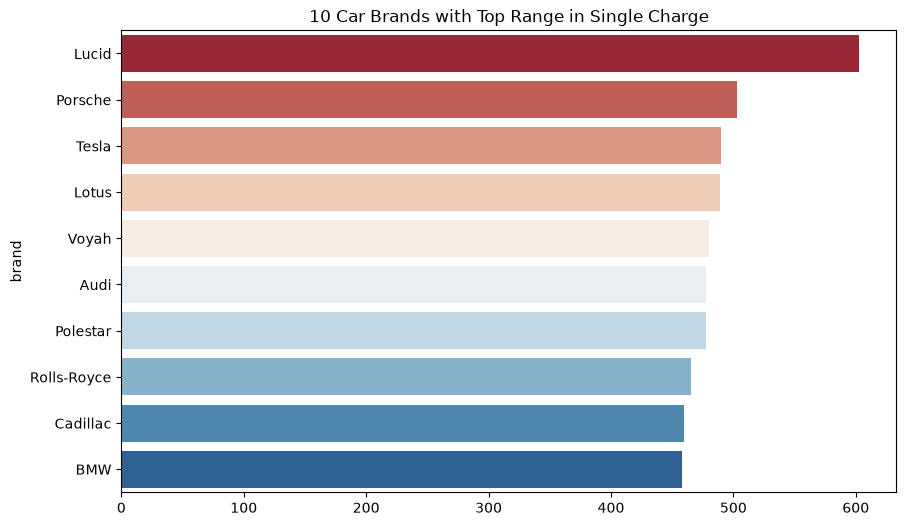

In [84]:
plt.figure(figsize=(10,6))

avg_top_range = df.groupby('brand')['range_km'].mean()
brand_top_range = avg_top_range.sort_values(ascending=False).round().head(10)


sns.barplot(x = brand_top_range.values, y = brand_top_range.index, palette = 'RdBu')
plt.title("10 Car Brands with Top Range in Single Charge")


### # Which body type dominates the EV market

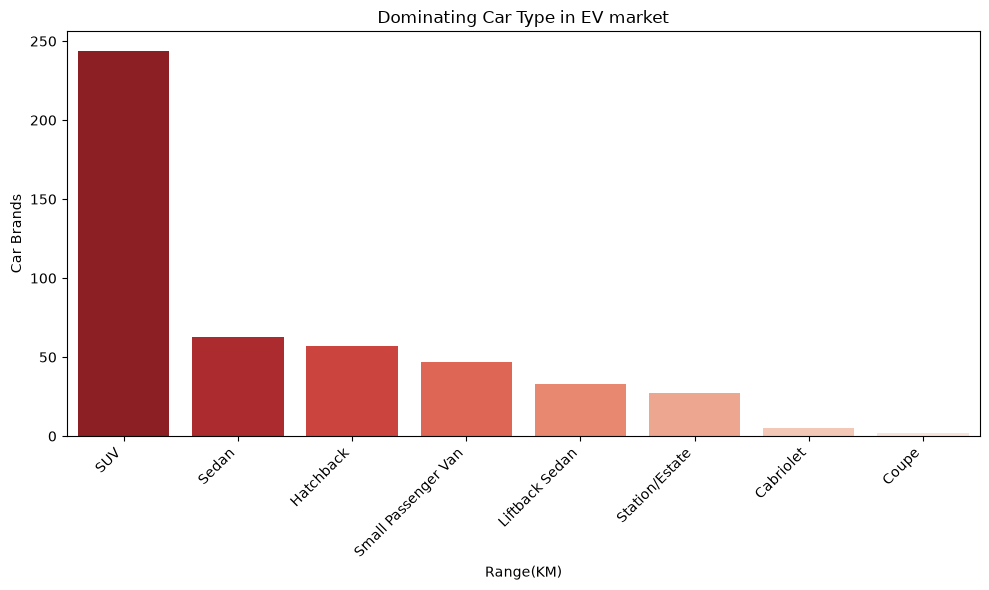

In [85]:
plt.figure(figsize=(10,6))

dom_cartype = df['car_body_type'].value_counts()
sns.barplot(y = dom_cartype.values,x =dom_cartype.index, palette= 'Reds_r')
plt.xlabel("Range(KM)")
plt.ylabel("Car Brands")

plt.xticks(rotation = 45, ha = 'right')
plt.title("Dominating Car Type in EV market")
plt.tight_layout()
plt.show()

### # Which brand builds the most energy-efficient fleet on average?


The Most efficient brand which builds the most energy efficent fleet on average:




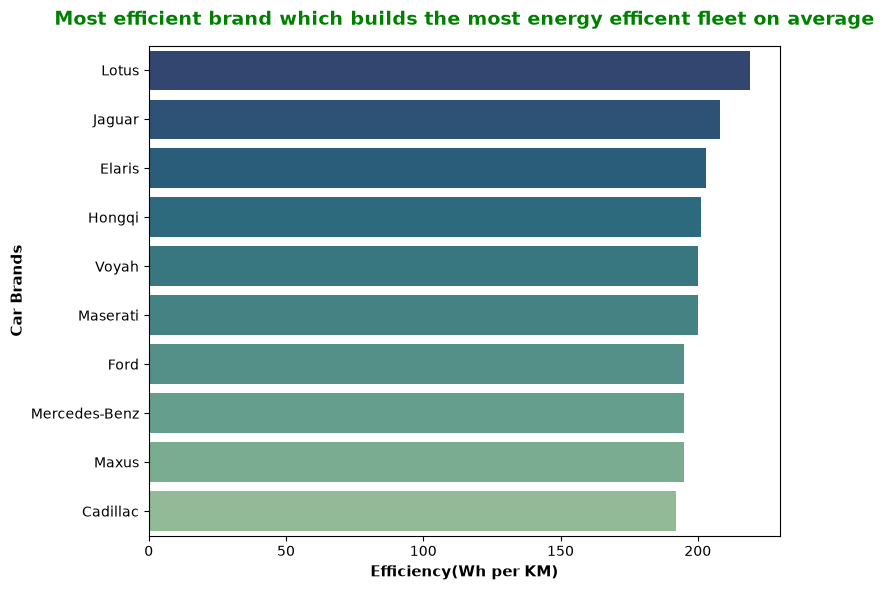

In [86]:
most_efficient = df.groupby('brand')['efficiency_wh_per_km'].mean().round()
print("The Most efficient brand which builds the most energy efficent fleet on average:\n\n")
sorted = most_efficient.sort_values(ascending =False).head(10)

plt.figure(figsize=(8,6))

sns.barplot(x=sorted.values, y=sorted.index, palette='crest_r')
plt.title("Most efficient brand which builds the most energy efficent fleet on average",fontsize = 14,fontweight ='bold', pad =15, color ='green' )
plt.xlabel("Efficiency(Wh per KM)", fontsize = 11,fontweight ='bold')
plt.ylabel("Car Brands", fontsize = 11,fontweight ='bold')
plt.tight_layout()
plt.show()

In [87]:
sorted

brand
Lotus            219.0
Jaguar           208.0
Elaris           203.0
Hongqi           201.0
Voyah            200.0
Maserati         200.0
Ford             195.0
Mercedes-Benz    195.0
Maxus            195.0
Cadillac         192.0
Name: efficiency_wh_per_km, dtype: float64

### # Does the data prove that AWD drivetrains have faster acceleration times?


AWD Drivetrains have faster acceleration.
              torque_nm  acceleration_0_100_s
drivetrain                                  
AWD         740.141361              4.553927
FWD         271.179487              9.730128
RWD         420.366412              6.887023


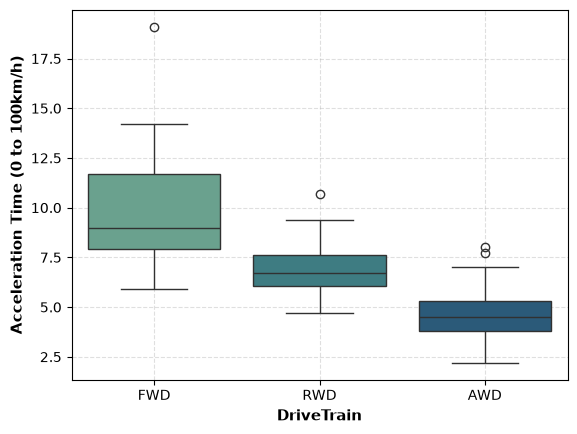

In [88]:
df.head(5)
groupped = df.groupby('drivetrain')[['torque_nm','acceleration_0_100_s']].mean()
print("AWD Drivetrains have faster acceleration.\n",groupped)
sns.boxplot(df, x = 'drivetrain', y='acceleration_0_100_s', palette = 'crest')
plt.ylabel('Acceleration Time (0 to 100km/h)', fontweight ='bold',fontsize = 11)
plt.xlabel('DriveTrain', fontweight ='bold',fontsize = 11)
plt.grid(visible = True, linestyle ='--', alpha =0.4)




### # What are the top 3 most common car_body types within this heavy-duty bracket?

Text(0, 0.5, 'Body Style')

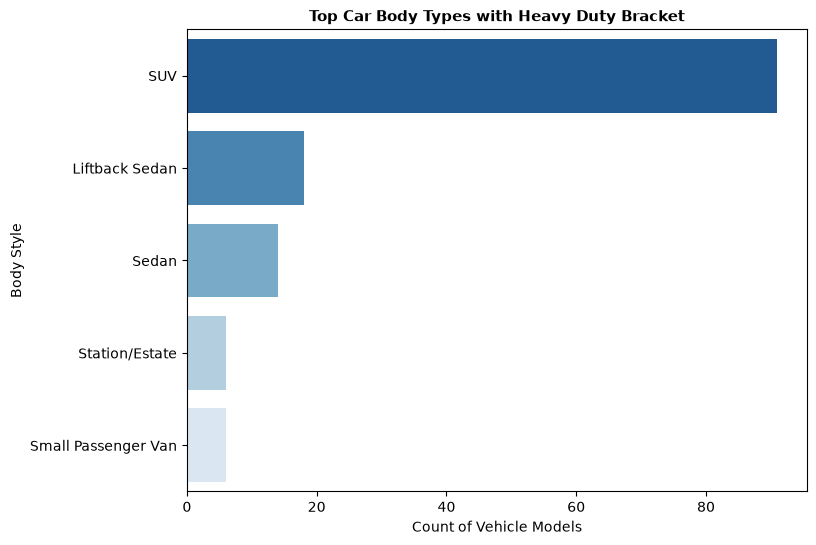

In [95]:
heavy_duty = df[df['towing_capacity_kg'] > 1500]['car_body_type'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=heavy_duty.values, y=heavy_duty.index, 
            palette='Blues_r')

plt.title('Top Car Body Types with Heavy Duty Bracket', fontweight = 'bold', fontsize =11)
plt.xlabel("Count of Vehicle Models")
plt.ylabel("Body Style")


### # Does a bigger battery always mean more range?



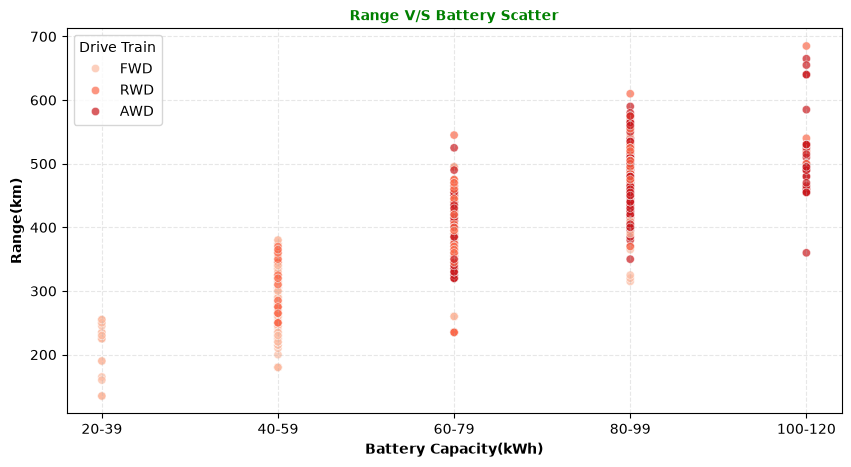

In [90]:
plt.figure(figsize=(10,5))

sns.scatterplot(data = df,x = 'battery_capacity_range', y = 'range_km',
                hue = 'drivetrain',
                palette = 'Reds',
                alpha = 0.7)

plt.title('Range V/S Battery Scatter',fontsize=10, fontweight='bold', color='green')
plt.xlabel('Battery Capacity(kWh)', fontsize=10, fontweight='bold')
plt.ylabel("Range(km)", fontsize=10, fontweight='bold')
plt.grid(visible=True, linestyle='--', alpha=0.3)
plt.legend(title = "Drive Train")
plt.show()

### # Top speeds Smooth Density Curve

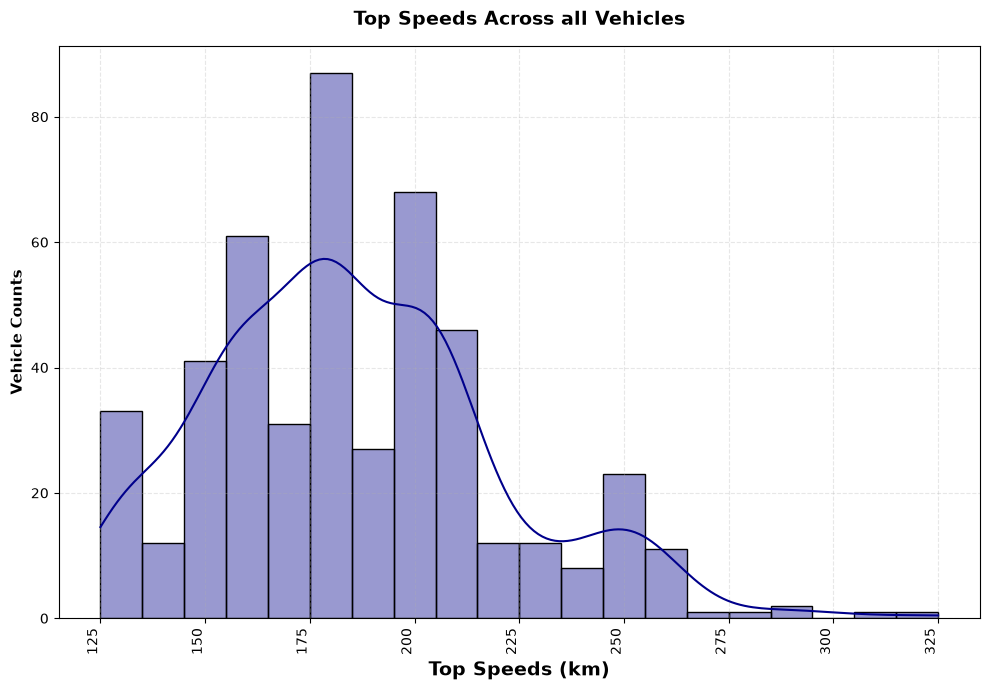

In [91]:
plt.figure(figsize= (10,7))

sns.histplot(data = df,
             x = 'top_speed_kmh',
             color = 'darkblue',
             bins = 20,
             kde = True,
             alpha = 0.4)

plt.xticks(rotation = 90, ha = 'right')
plt.title("Top Speeds Across all Vehicles", fontsize = 14,fontweight ='bold', pad =15)
plt.xlabel("Top Speeds (km)", fontsize = 14,fontweight ='bold') 
plt.ylabel("Vehicle Counts", fontsize = 11,fontweight ='semibold') 
plt.grid(visible=True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

###  # Car Size Classification based on type of Segment

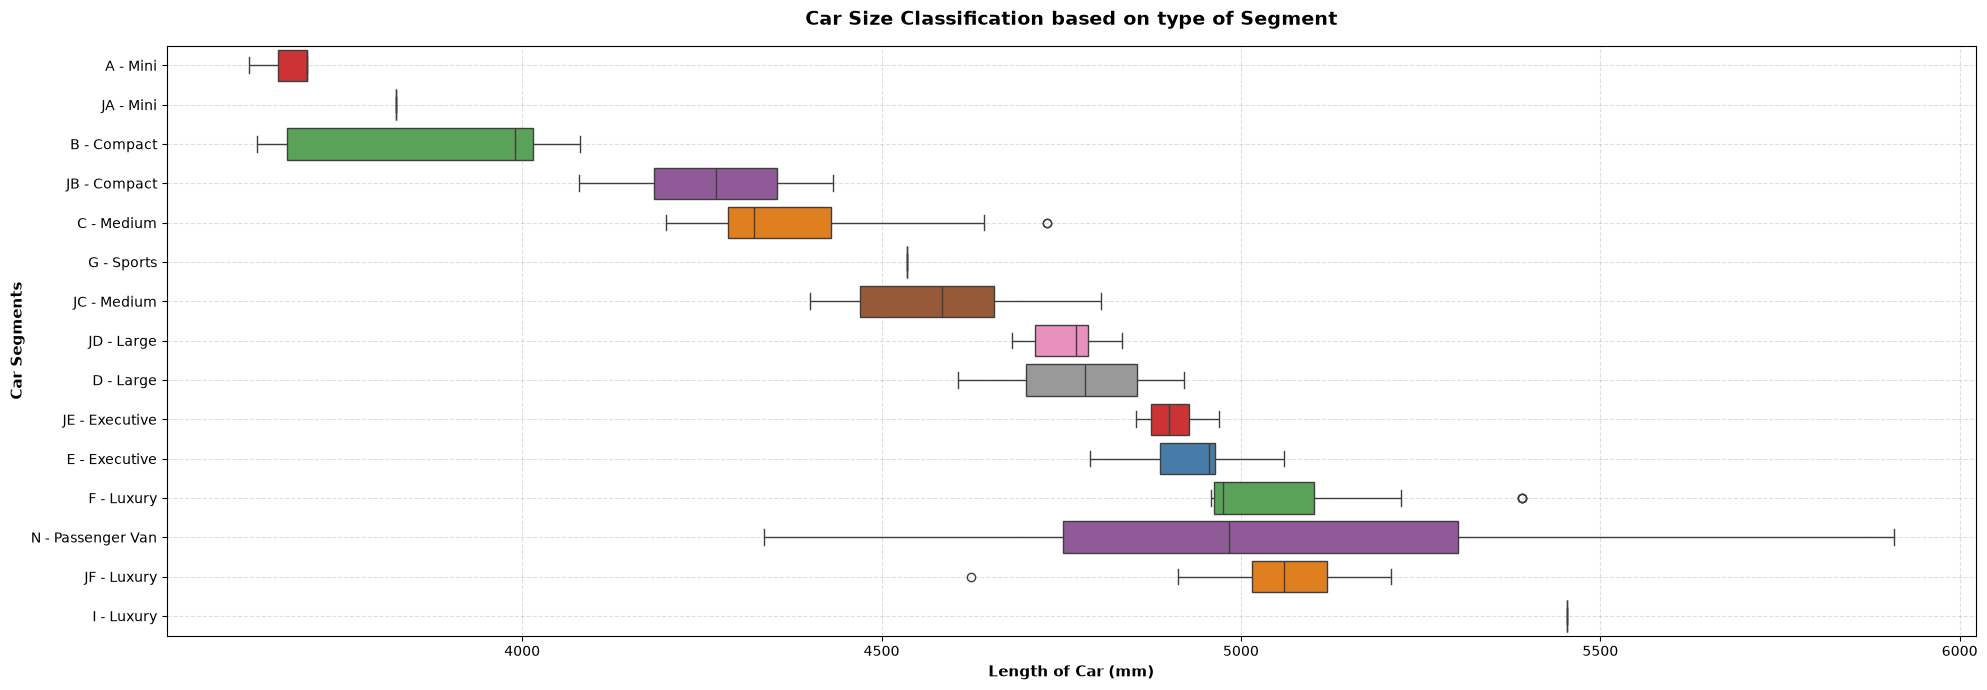

In [92]:
segment= df.groupby('segment')['length_mm'].median().sort_values().index
plt.figure(figsize = (20,7))

sns.boxplot(data = df, x = 'length_mm', y = 'segment',order = segment,palette = 'Set1')

plt.title("Car Size Classification based on type of Segment", fontsize = 14, fontweight= 'bold', pad =15)
plt.xlabel("Length of Car (mm)", fontsize = 11, fontweight= 'bold')
plt.ylabel("Car Segments", fontsize = 11, fontweight= 'bold')
plt.grid(visible = True, linestyle = '--', alpha =0.4)
plt.tight_layout()
plt.show()


### # Correlation Heatmap Matrix

In [93]:
df.head()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,battery_capacity_range
0,Abarth,500e Convertible,155,37.8,Lithium-ion,235.0,156,225,7.0,67.0,...,0.0,185.0,4,FWD,B - Compact,3673,1683,1518,Hatchback,20-39
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,235.0,149,225,7.0,67.0,...,0.0,185.0,4,FWD,B - Compact,3673,1683,1518,Hatchback,20-39
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,345.0,158,280,5.9,79.0,...,0.0,360.0,5,FWD,JB - Compact,4187,1779,1557,SUV,40-59
3,Abarth,600e Turismo,200,50.8,Lithium-ion,345.0,158,280,6.2,79.0,...,0.0,360.0,5,FWD,JB - Compact,4187,1779,1557,SUV,40-59
4,Aiways,U5,150,60.0,Lithium-ion,310.0,156,315,7.5,78.0,...,1500.0,496.0,5,FWD,JC - Medium,4680,1865,1700,SUV,40-59


Text(0.5, 1.0, 'Correlation Heat Map')

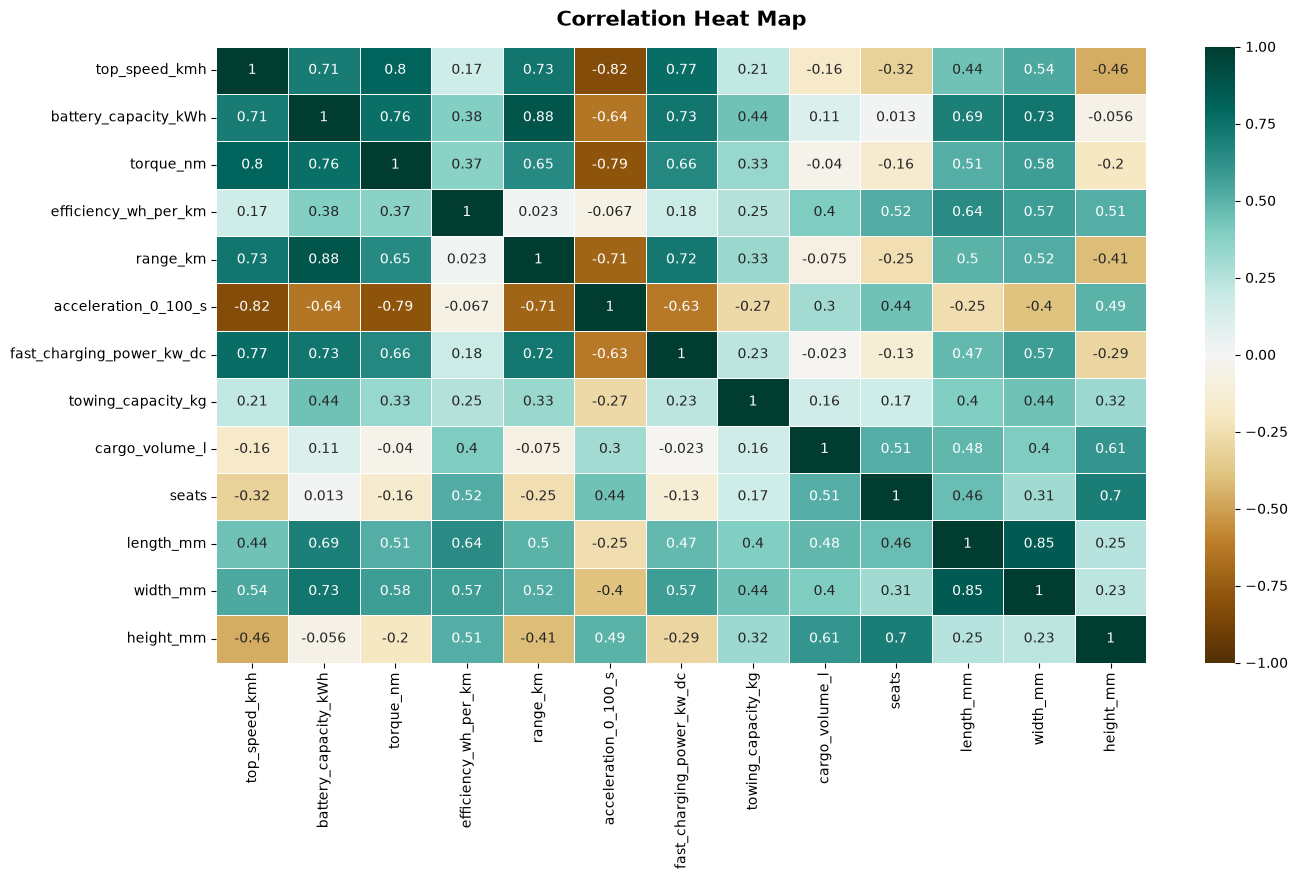

In [94]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, cmap = 'BrBG',linewidths=0.5, vmin= -1, vmax =1, annot=True)

plt.title("Correlation Heat Map",fontsize = 15, fontweight = 'bold', pad = 15)